Possible TO-DOs:
- color nodes based on labeling;
- color/have different shapes for edges based on their weights

# Step 6


- take the input graph (for instance Les Misérables network)
- compute similarity matrix using graph-theoretic distance
- project it using at least two different projections (MDS, t-SNE, ISOMAP)
- draw the resulting layouts
- compare/discuss the obtained layouts and parameter choices

In [1]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path
import matplotlib.cm as cm
from matplotlib.patches import Polygon, Patch, Rectangle
from scipy.spatial import ConvexHull
from sklearn.manifold import MDS, TSNE, Isomap
from sklearn.metrics import pairwise_distances

In [2]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/JazzNetwork.dot"
data_name_2 = "../Dataset/LesMiserables.dot" #
data_name_3 = "../Dataset/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/g.20.27.dot"
data_name_5 = "../Dataset/g.42.88.dot"
data_name_6 = "../Dataset/GD97.dot"
data_name_7 = "../Dataset/LeagueNetwork.dot" 
data_name_8 = "../Dataset/mesh graph.dot"
data_name_9 = "../Dataset/noname.dot" 
data_name_10 = "../Dataset/polblogs.dot"
data_name_11 = "../Dataset/robot graph.dot"
data_name_12 = "../Dataset/rome.dot"
data_name_13 = "../Dataset/snail graph.dot"

# Functions

In [3]:
def floyd_warshall(nodes_dict, edges_dict):
    """
    Implements the Floyd-Warshall algorithm to find shortest paths between all pairs of nodes in a graph.
    
    Input:
    - nodes_dict: A list of dictionaries where each dict contains 'node_id' and other attributes
    - edges_dict: A list of dictionaries where each dict contains 'edge_nodes' (source, target) tuple
                  and other attributes including possibly weight information
    
    Output:
    - distance_matrix: A 2D matrix where distance_matrix[i][j] is the shortest path distance from node i to node j
    - node_ids: The list of node IDs in the order they appear in the distance matrix
    
    Algorithm explanation:
    The Floyd-Warshall algorithm finds shortest paths between all pairs of nodes by:
    1. Initializing a distance matrix D with infinity for all non-adjacent nodes
    2. Setting D[i,i] = 0 for all nodes (distance from a node to itself)
    3. Setting D[i,j] = weight for each direct edge (i,j)
    4. Considering each node k as a potential intermediate in paths between i and j
    5. If going through k yields a shorter path, updating D[i,j] accordingly
    
    Time Complexity: O(|V|³) where |V| is the number of nodes
    Space Complexity: O(|V|²)
    """
    
    # Extract node IDs from nodes_dict
    node_ids = [node['node_id'] for node in nodes_dict]
    n = len(node_ids)
    
    # Create node to index mapping for the matrix
    node_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
    
    # Initialize distance matrix with infinity
    distance_matrix = [[float('inf') for _ in range(n)] for _ in range(n)]
    
    # Set diagonal elements to 0 (distance from a node to itself)
    for i in range(n):
        distance_matrix[i][i] = 0
    
    # Set edge weights
    for edge in edges_dict:
        source, target = edge['edge_nodes']
        
        # Clean up node IDs (remove quotes if present)
        source = source.strip('"')
        target = target.strip('"')
        
        if source in node_to_idx and target in node_to_idx:
            # Determine the weight - look for a weight attribute, default to 1 if not found
            weight = 1
            if 'weight' in edge:
                try:
                    weight = float(edge['weight'].strip('"'))
                except (ValueError, AttributeError):
                    weight = 1
            elif 'len' in edge:
                try:
                    weight = float(edge['len'].strip('"'))
                except (ValueError, AttributeError):
                    weight = 1
                
            i, j = node_to_idx[source], node_to_idx[target]
            distance_matrix[i][j] = weight
            
            # If the graph is undirected, add the reverse edge as well
            # Uncomment this if your graph is undirected
            # distance_matrix[j][i] = weight
    
    # Floyd-Warshall algorithm
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if distance_matrix[i][j] > distance_matrix[i][k] + distance_matrix[k][j]:
                    distance_matrix[i][j] = distance_matrix[i][k] + distance_matrix[k][j]
    
    return distance_matrix, node_ids

# Example usage
def get_shortest_distance(source, target, distance_matrix, node_ids):
    """
    Get the shortest distance between two nodes.
    
    Input:
    - source: The ID of the source node
    - target: The ID of the target node
    - distance_matrix: The distance matrix from floyd_warshall
    - node_ids: The list of node IDs from floyd_warshall
    
    Output:
    - The shortest distance from source to target
    """
    try:
        i = node_ids.index(source)
        j = node_ids.index(target)
        return distance_matrix[i][j]
    except ValueError:
        return "Node not found in the graph"
    
def plot_distance_matrix_with_weights(distance_matrix, node_ids=None, cmap='viridis_r', figsize=(10, 8)):
    """
    Visualizes the distance matrix from Floyd-Warshall algorithm as a heatmap with annotations.
    
    Parameters:
    - distance_matrix: 2D matrix of shortest path distances between all pairs of nodes
    - node_ids: List of node IDs in the order they appear in the distance matrix (optional)
    - cmap: Colormap to use for the heatmap (default: 'viridis_r')
    - figsize: Figure size (width, height) in inches
    
    Returns:
    - matplotlib figure and axes objects
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Convert to numpy array if not already
    distance_matrix = np.array(distance_matrix)
    
    # Create a masked array for infinity values
    mask = np.isinf(distance_matrix)
    masked_matrix = np.ma.masked_array(distance_matrix, mask)
    
    # Create figure and axes
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot heatmap
    im = ax.imshow(masked_matrix, cmap=cmap)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Shortest Path Distance')
    
    # Set title and labels
    ax.set_title('Shortest Path Distances (Floyd-Warshall Algorithm)')
    
    if node_ids is not None:
        # Clean node IDs (remove quotes if present)
        clean_node_ids = [nid.strip('"') if isinstance(nid, str) else nid for nid in node_ids]
        
        # Only show node labels if there are not too many
        if len(node_ids) <= 30:
            ax.set_xticks(np.arange(len(node_ids)))
            ax.set_yticks(np.arange(len(node_ids)))
            ax.set_xticklabels(clean_node_ids, rotation=45, ha='right')
            ax.set_yticklabels(clean_node_ids)
    
    ax.set_xlabel('Destination Node')
    ax.set_ylabel('Source Node')
    
    # Add text annotations with distances
    if distance_matrix.shape[0] <= 20:  # Only add annotations for smaller matrices
        for i in range(distance_matrix.shape[0]):
            for j in range(distance_matrix.shape[1]):
                value = distance_matrix[i, j]
                text = 'Inf' if np.isinf(value) else f'{value:.1f}'
                text_color = 'white' if not np.isinf(value) and value > np.nanmean(masked_matrix) else 'black'
                ax.text(j, i, text, ha='center', va='center', color=text_color)
    
    # Add a grid to better separate cells
    ax.set_xticks(np.arange(distance_matrix.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(distance_matrix.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=1)
    
    plt.tight_layout()
    return fig, ax

# Usage:

## take the input graph and compute similarity matrix using graph-theoretic distance

In [4]:
# Load the graph directly with NetworkX
nx_graph = nx.nx_pydot.read_dot(data_name_2)

# Check graph type
is_directed = nx.is_directed(nx_graph)
print(f"Graph is {'directed' if is_directed else 'undirected'}")

# Extract nodes and edges and their attributes
nodes = nx_graph.nodes(data=True)
edges = nx_graph.edges(data=True)

# Create an array of dictionaries, one for each edge
edges_dict = []
for source, target, attrs in edges:
    # Add the original edge direction
    edge_dict = {
        "edge_nodes": (source, target),
        "directed": is_directed
    }
    
    # Add all attributes from the attrs dictionary
    for attr_name, attr_value in attrs.items():    
        edge_dict[attr_name] = attr_value
    
    edges_dict.append(edge_dict)
    
    # For undirected graphs, add the reverse edge as well
    if not is_directed:
        reverse_edge_dict = {
            "edge_nodes": (target, source),
            "directed": is_directed
        }
        
        # Copy all attributes from the original edge
        for attr_name, attr_value in attrs.items():    
            reverse_edge_dict[attr_name] = attr_value
        
        edges_dict.append(reverse_edge_dict)

nodes_dict = []
for node_id, attrs in nodes:
    node_dict = {
        "node_id": node_id
    }
    
    # Add all attributes from the attrs dictionary
    for attr_name, attr_value in attrs.items():        
        node_dict[attr_name] = attr_value
    
    nodes_dict.append(node_dict)

# Basic graph information
print(f"Number of nodes: {len(nodes)}")
if is_directed:
    print(f"Number of edges: {len(edges)}")
else:
    print(f"Original Number of Edges:  {len(edges)} \n -- after doubling edges -- \nNumber of edges: {len(edges) * (2 if not is_directed else 1)}")

Graph is undirected
Number of nodes: 77
Original Number of Edges:  254 
 -- after doubling edges -- 
Number of edges: 508


Calaculating shortest paths for all pairs of nodes in the graph with Floyd-Warshall’s Algorithm. Furthermore, we're calculating the distance matrix, to be able to run MDS, t-SNE and ISOMAP:

In [5]:
# Compute all-pairs shortest paths
distance_matrix, node_ids = floyd_warshall(nodes_dict, edges_dict)

# Example: Find shortest distance between all possible pairs of two nodes
for source in node_ids:
    for target in node_ids:
        if source != target:
            print(f"Shortest distance from {source} to {target}: {get_shortest_distance(source, target, distance_matrix, node_ids)}")

Shortest distance from 1 to 2: 1.0
Shortest distance from 1 to 3: 9.0
Shortest distance from 1 to 4: 9.0
Shortest distance from 1 to 5: 2.0
Shortest distance from 1 to 6: 2.0
Shortest distance from 1 to 7: 2.0
Shortest distance from 1 to 8: 2.0
Shortest distance from 1 to 9: 3.0
Shortest distance from 1 to 10: 2.0
Shortest distance from 1 to 11: 6.0
Shortest distance from 1 to 12: 7.0
Shortest distance from 1 to 13: 7.0
Shortest distance from 1 to 14: 7.0
Shortest distance from 1 to 15: 7.0
Shortest distance from 1 to 16: 7.0
Shortest distance from 1 to 24: 9.0
Shortest distance from 1 to 25: 8.0
Shortest distance from 1 to 26: 8.0
Shortest distance from 1 to 27: 9.0
Shortest distance from 1 to 28: 8.0
Shortest distance from 1 to 29: 9.0
Shortest distance from 1 to 30: 8.0
Shortest distance from 1 to 32: 9.0
Shortest distance from 1 to 33: 7.0
Shortest distance from 1 to 34: 8.0
Shortest distance from 1 to 35: 9.0
Shortest distance from 1 to 36: 9.0
Shortest distance from 1 to 37: 8.0


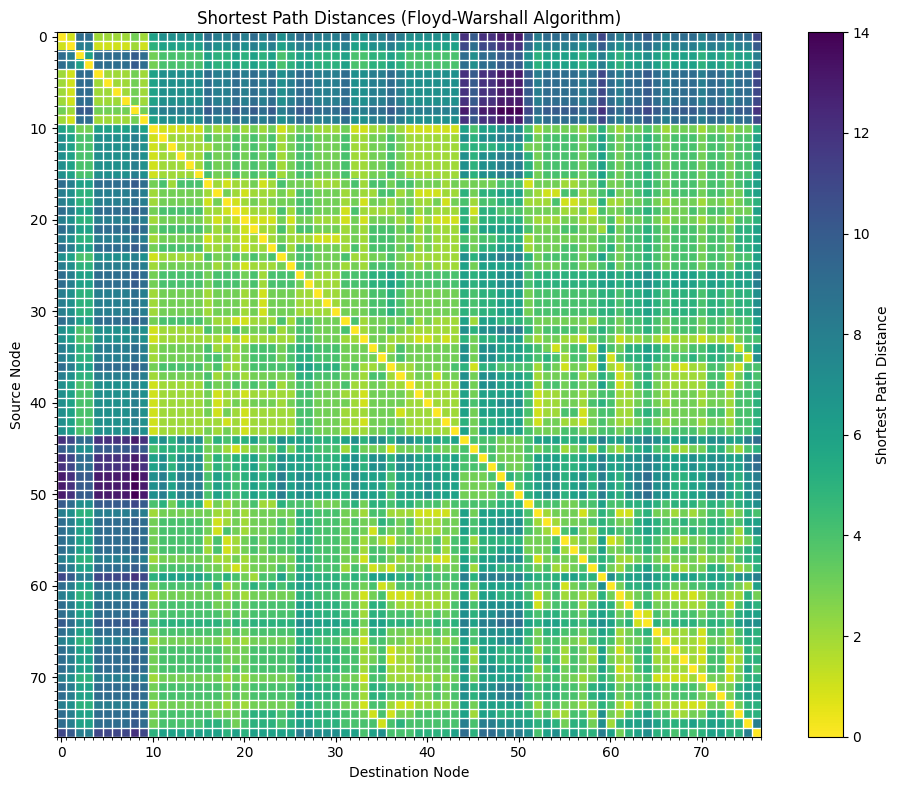

In [6]:
# Drawing Distance Matrix:
fig, ax = plot_distance_matrix_with_weights(distance_matrix, node_ids)
plt.show()

## project it using at least two different projections (MDS, t-SNE, ISOMAP)

Preliminary adjustments on the distance matrix format:

In [7]:
# Convert the distance matrix to a NumPy array
distance_matrix_np = np.array(distance_matrix)

### MDS

In [8]:
n_components = 2  
mds = MDS(n_components=n_components)

# Fit the MDS model to your data
mds_distance_matrix_reduced = mds.fit_transform(distance_matrix_np)

print('Dimesnion of X after MDS = ',mds_distance_matrix_reduced.shape)

Dimesnion of X after MDS =  (77, 2)


/Users/edo/Desktop/UniTrieste/2°sem_2°anno/erasmus/01_Data_Visualization/project/step_5/Data-Visualization-CurryPasta/dv-env/lib/python3.11/site-packages/sklearn/manifold/_mds.py:632: UserWarning: The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.
  warnings.warn(


### t-SNE

In [9]:
# Run t-SNE with precomputed distances
tsne = TSNE(
    n_components=2,           # Reduce to 2 dimensions for visualization
    metric='precomputed',     # This is crucial - tells t-SNE we're providing distances
    learning_rate='auto',     
    init='random',            
    perplexity=3,             # Good choice for small datasets
    random_state=42           # For reproducibility
)

# Apply t-SNE to the NumPy array version of the distance matrix
tsne_distance_matrix_reduced = tsne.fit_transform(distance_matrix_np)
print('Dimesnion of X after t-SNE = ', tsne_distance_matrix_reduced.shape)

Dimesnion of X after t-SNE =  (77, 2)


### ISOMAP

In [10]:
# Ensure distance matrix is a numpy array
distance_matrix_np = np.array(distance_matrix)

# Create Isomap object
isomap = Isomap(
    n_components=2,          # Reduce to 2 dimensions
    metric='precomputed',    # Indicate we're using a precomputed distance matrix
    n_neighbors=5            # Number of neighbors to consider for each point
)

# Apply Isomap to the distance matrix
isomap_results = isomap.fit_transform(distance_matrix_np)
print('Dimension of X after Isomap =', isomap_results.shape)

Dimension of X after Isomap = (77, 2)


/Users/edo/Desktop/UniTrieste/2°sem_2°anno/erasmus/01_Data_Visualization/project/step_5/Data-Visualization-CurryPasta/dv-env/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/edo/Desktop/UniTrieste/2°sem_2°anno/erasmus/01_Data_Visualization/project/step_5/Data-Visualization-CurryPasta/dv-env/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


## draw the resulting layouts and compare/discuss the obtained layouts and parameter choices

### MDS

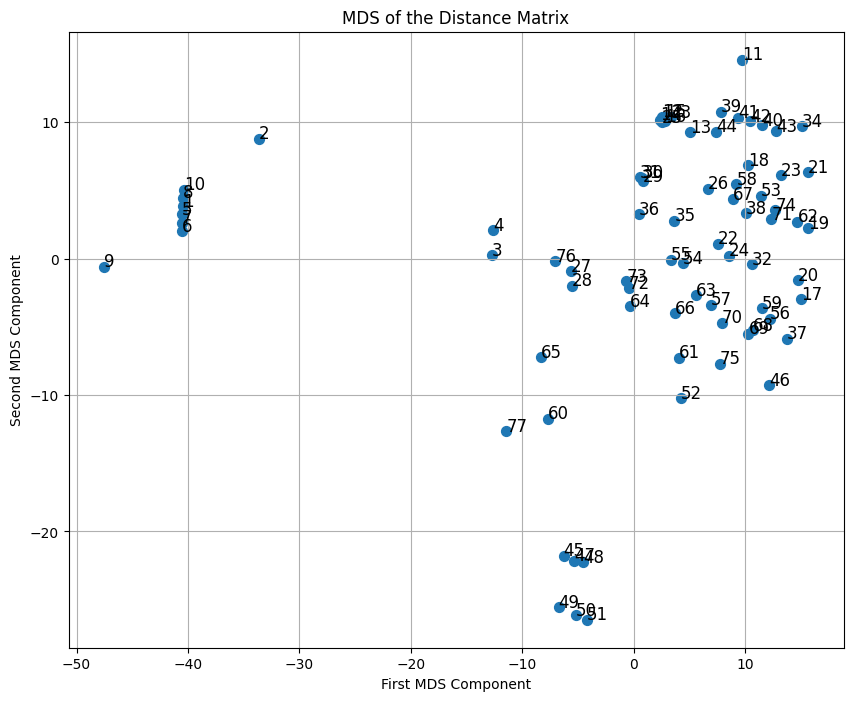

In [11]:
# Plot the reduced data
plt.figure(figsize=(10, 8))
plt.scatter(mds_distance_matrix_reduced[:, 0], mds_distance_matrix_reduced[:, 1], s=50)

# Add labels for each point
for i in range(len(mds_distance_matrix_reduced)):
    node_label = str(i+1)  # Adjust if you have actual node IDs
    plt.annotate(node_label, 
                 (mds_distance_matrix_reduced[i, 0], mds_distance_matrix_reduced[i, 1]), 
                 fontsize=12)

plt.title("MDS of the Distance Matrix")
plt.xlabel("First MDS Component")
plt.ylabel("Second MDS Component")
plt.grid(True)
plt.show()

### t-SNE

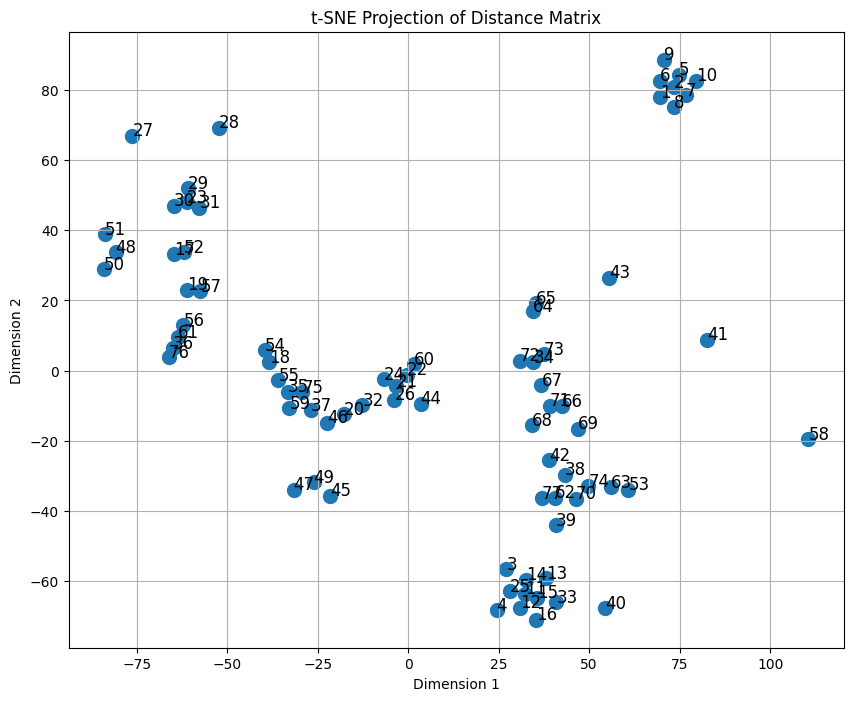

In [12]:
# Visualize the result
plt.figure(figsize=(10, 8))
plt.scatter(tsne_distance_matrix_reduced[:, 0], tsne_distance_matrix_reduced[:, 1], s=100)

# Add labels for each point
for i in range(len(tsne_distance_matrix_reduced)):
    node_label = str(i+1)  # Adjust if you have actual node IDs
    plt.annotate(node_label, 
                 (tsne_distance_matrix_reduced[i, 0], tsne_distance_matrix_reduced[i, 1]), 
                 fontsize=12)

plt.title('t-SNE Projection of Distance Matrix')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)
plt.show()

### ISOMAP

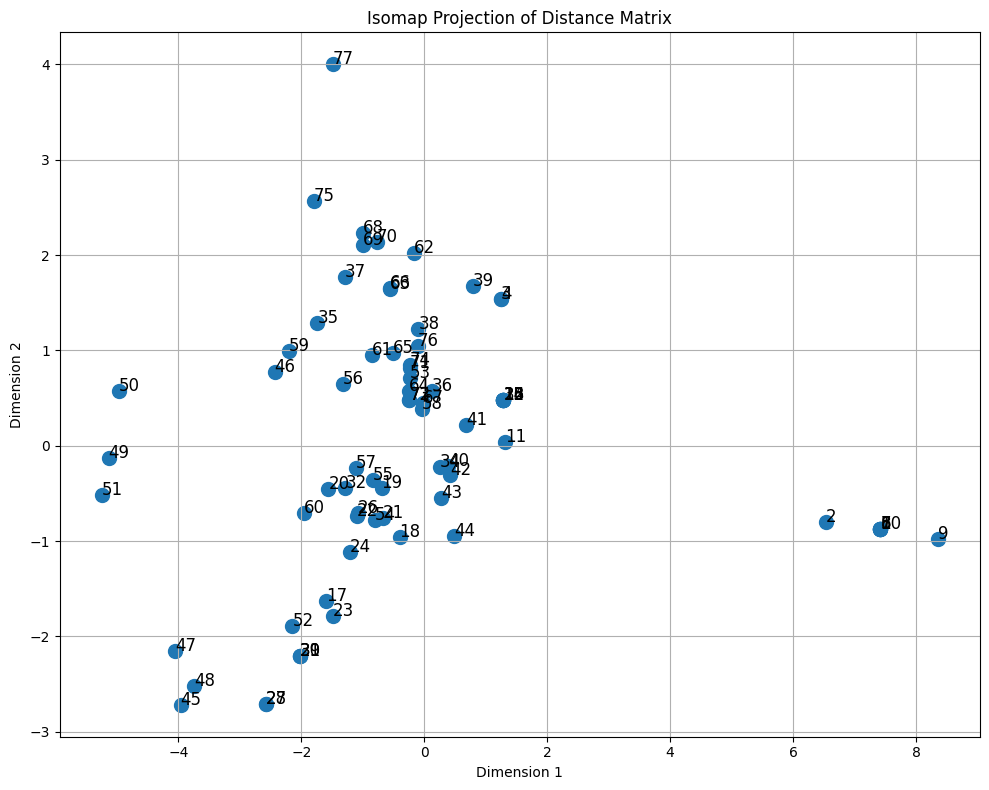

In [13]:

# Visualize the results
plt.figure(figsize=(10, 8))
plt.scatter(isomap_results[:, 0], isomap_results[:, 1], s=100)

# Add labels for each point
for i in range(len(isomap_results)):
    node_label = str(i+1)  # Adjust if you have actual node IDs
    plt.annotate(node_label, 
                (isomap_results[i, 0], isomap_results[i, 1]), 
                fontsize=12)

plt.title('Isomap Projection of Distance Matrix')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)
plt.tight_layout()
plt.show()